In [16]:
rsnapsim_dir = r'C:\Users\Willi\Documents\Github\rSNAPsim'
rsnaped_dir = r'C:\Users\Willi\Documents\Github\rSNAPed'
gene_file = r'C:\Users\Willi\Documents\data_for_tim\pGG167(12xST-KDM5B-BoxB-MS2).dna'
rsnaped_settings_yaml = r'C:\Users\Willi\Documents\Github\rSNAPed\kdm5b.yaml'

In [7]:
%%capture
import os; from os import listdir; from os.path import isfile, join
import re  
from skimage.io import imread
from skimage.exposure import rescale_intensity
import numpy as np 
from tqdm.notebook import tqdm
from timeit import default_timer as timer
import scipy
import pandas as pd
import shutil
import pathlib
import sys
import seaborn as sns
from skimage.measure import approximate_polygon
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

import os
homedir = os.getcwd()
os.chdir(homedir)
os.chdir(rsnapsim_dir)
import rsnapsim as rsnp
os.chdir(homedir)

import scipy.stats as stats
import matplotlib.pyplot as plt 

plt.style.use("dark_background")

# Defining directories
current_dir = pathlib.Path(rsnaped_dir).absolute()
sequences_dir = current_dir.joinpath('DataBases','gene_files')
video_dir = current_dir.joinpath('DataBases','videos_for_sim_cell')
masks_dir = current_dir.joinpath('DataBases','masks_for_sim_cell')

# Importing rSNAPed
sys.path.append(str(current_dir.joinpath('rsnaped')))
import rsnaped as rsed


from IPython.display import HTML
import matplotlib.pyplot as plt
import matplotlib.animation 
import numpy as np

import matplotlib.animation as mpani

import yaml

## rSNAPsim models

In [ ]:
###############################################################################
# Load the kdm5b sequence
###############################################################################

# overwrite mRNA 1, manually overwrite the kdm5b yaml with the correct CDS since by default it uses the first largest CDS.
_,_,tagged_CDSs,_ = rsnp.seqmanip.open_seq_file(str(gene_file), add_tag=False)

KDM5B_12xSun = tagged_CDSs['+1'][0]

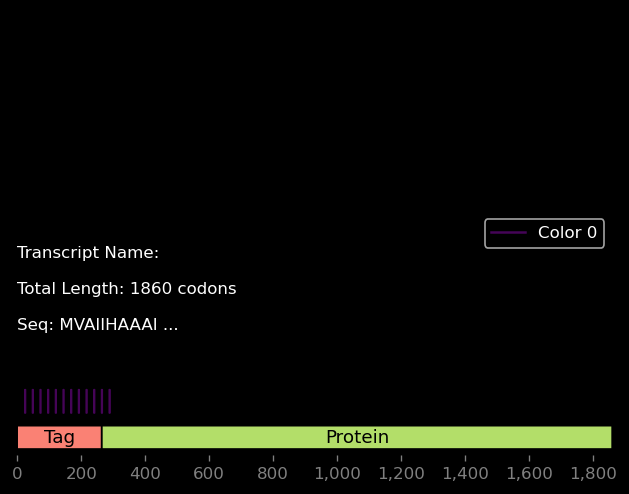

In [18]:
KDM5B_12xSun.visualize_mrna_strand()

In [26]:
print('\n'.join( [KDM5B_12xSun.aa_seq[i:i+80] for i in range(0, int(len(KDM5B_12xSun.aa_seq)), 80)] ))

MVAIIHAAAIIGPGGSGGGGSGGEELLSKNYHLENEVARLKKGSGSGEELLSKNYHLENEVARLKKGSGSGEELLSKNYH
LENEVARLKKGSGSGEELLSKNYHLENEVARLKKGSGSGEELLSKNYHLENEVARLKKGSGSGEELLSKNYHLENEVARL
KKGSGSGEELLSKNYHLENEVARLKKGSGSGEELLSKNYHLENEVARLKKGSGSGEELLSKNYHLENEVARLKKGSGSGE
ELLSKNYHLENEVARLKKGSGSGEELLSKNYHLENEVARLKKGSGSGEELLSKNYHLENEVARLKKGSGSGAIAMEAATT
LHPGPRPALPLGGPGPLGEFLPPPECPVFEPSWEEFADPFAFIHKIRPIAEQTGICKVRPPPDWQPPFACDVDKLHFTPR
IQRLNELEAQTRVKLNFLDQIAKYWELQGSTLKIPHVERKILDLFQLNKLVAEEGGFAVVCKDRKWTKIATKMGFAPGKA
VGSHIRGHYERILNPYNLFLSGDSLRCLQKPNLTTDTKDKEYKPHDIPQRQSVQPSETCPPARRAKRMRAEAMNIKIEPE
ETTEARTHNLRRRMGCPTPKCENEKEMKSSIKQEPIERKDYIVENEKEKPKSRSKKATNAVDLYVCLLCGSGNDEDRLLL
CDGCDDSYHTFCLIPPLHDVPKGDWRCPKCLAQECSKPQEAFGFEQAARDYTLRTFGEMADAFKSDYFNMPVHMVPTELV
EKEFWRLVSTIEEDVTVEYGADIASKEFGSGFPVRDGKIKLSPEEEEYLDSGWNLNNMPVMEQSVLAHITADICGMKLPW
LYVGMCFSSFCWHIEDHWSYSINYLHWGEPKTWYGVPGYAAEQLENVMKKLAPELFVSQPDLLHQLVTIMNPNTLMTHEV
PVYRTNQCAGEFVITFPRAYHSGFNQGFNFAEAVNFCTVDWLPLGRQCVEHYRLLHRYCVFSHDEMICKMASKADVLDVV
VASTVQKDMAIMIEDEKALRETVRKLGV

In [30]:
###############################################################################
# Make a new custom model for kdm5b 12xSun that can FRAP or ROA
###############################################################################

recompile_model = True
if not recompile_model:
    try:
        model = rsnp.tasep_model('kdm5b_12xSun_ROA_FRAP') # model object
        model.load_saved_cmodel('kdm5b_12xSun_ROA_FRAP')
        make_model = 0
    except:
        print('Could not load saved c++ model..... attempting to recompile')
        make_model = 1
else:
    make_model = 1
if make_model:

    # Make the mRNA object
    mRNA = KDM5B_12xSun                           # pull out the main open reading frame
    mRNA.ke_mu = 5
    mRNA_length = len(mRNA.kelong)                  # get the length of the mRNA
    mRNA.generate_3frame_tags()                     # call to generate all open reading frames
    
    model = rsnp.tasep_model('kdm5b_12xSun_ROA_FRAP', mRNA=mRNA) # model object
    
    
    # Make the kelong mat (manually adding an extra location that is equal to zero, so particles dont run over the simulation)
    kelong_mat = np.zeros([3, mRNA_length+1])
    kelong_mat[0, :-1] = mRNA.kelong
    #kelong_mat[1, :-2] = propf.get_k(mRNA.nt_seq[1:-2], .1, 10, 10)[1:-1]
    #kelong_mat[2, :-2] = propf.get_k(mRNA.nt_seq[2:-1], .1, 10, 10)[1:-1]
    kelong_mat[0, -2] = 0
    
    model._kelong_mat = kelong_mat #override the current kelongation mat
    
    t_harringtonine = 1e6
    t_FRAP = 1e6
    FRAP_length = 10 # ten seconds
    footprint = 9
    parameters = [0.033, 5, mRNA_length, t_harringtonine, t_FRAP, FRAP_length]
    
    # DEFAULT STEPPING INITIATION
    init = lambda k,t,p,ke,o,l,pr,s,r,nr: (1-np.any(l[0:0+footprint]))*k[0]*(t < k[3])
    model.add_lattice_reaction(init, rxn_name = 'initiation', frame=0, loc=0, dexist=1,)
    
    # DEFAULT TERMINATION 
    leave = lambda k,t,p,ke,o,l,pr,s,r,nr: l[k[2]-1]*k[1] #(lattice location 590 = 1) * parameter
    model.add_lattice_reaction(leave, rxn_name='termination', frame=0, loc=1859, dexist=-1,)
    
    FRAP = lambda k,t,p,ke,o,l,pr,s,r,nr: [10000*(t > k[4])*(t < k[4]+k[5])*(p[i,4] > 0) for i in range(nr)]
    model.add_ribosome_reaction(FRAP, rxn_name='frap', dprobes=[-1], dprobe_inds=[0]) 
    
    
    # DEFAULT STEPPING OF ELONGATION USING THE ELONGATION MATRIX
    #default stepping
    elong_step = lambda k,t,p,ke,o,l,pr,s,r,nr: [ (ke[p[i,2], p[i,3]])*(1 - sum(l[p[i,3]+1:p[i,3]+footprint])) for i in range(nr)]
    model.add_ribosome_reaction(elong_step, rxn_name='elongation', dloc=1) 
    
    # finally specify which reactions are ribosome specific
    model._ribosome_reactions = [2,3]
    model._constant_reactions = [0,1,]
    model._lattice_arr0 = np.zeros([model._length+1], dtype=int)
    
    model.compile_model_c()


eigen instillation found...
['c:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\', 'c:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\', 'c:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\', 'c:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\']
['c:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\', 'c:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\', 'c:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\', 'c:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\']
converting propensities to c...
[<function <lambda> at 0x0000025A80000A40>, <function <lambda> at 0x0000025A808E1620>]
 (1-np.any(l[0:0+footprint]))*k[0]*(t < k[3])
 (1-np.any(l[0:0+footprint]))*k[0]*(t < k[3])
Detected comment:

fstring:
 (1-np.any(l[0:0+footprint]))*k[0]*(t < k[3])
 (1-np.any(l[0:0+footprint]))*k[0]*(t < k[3])
[0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[False, False, True, False, False, Fals

In [ ]:
t_harr = 1000
t_FRAP = 1e6
t_FRAP_stop = 1e6+10

k_init = 0.033
ke_mu = 5
model.set_parameters([k_init, ke_mu, len(KDM5B_12xSun.kelong), t_harr, t_FRAP, t_FRAP_stop,]) # how do we change parameters now?
soln = rsnp.solver.solve_ssa(model, np.linspace(0,2000,2001), cplus=True)

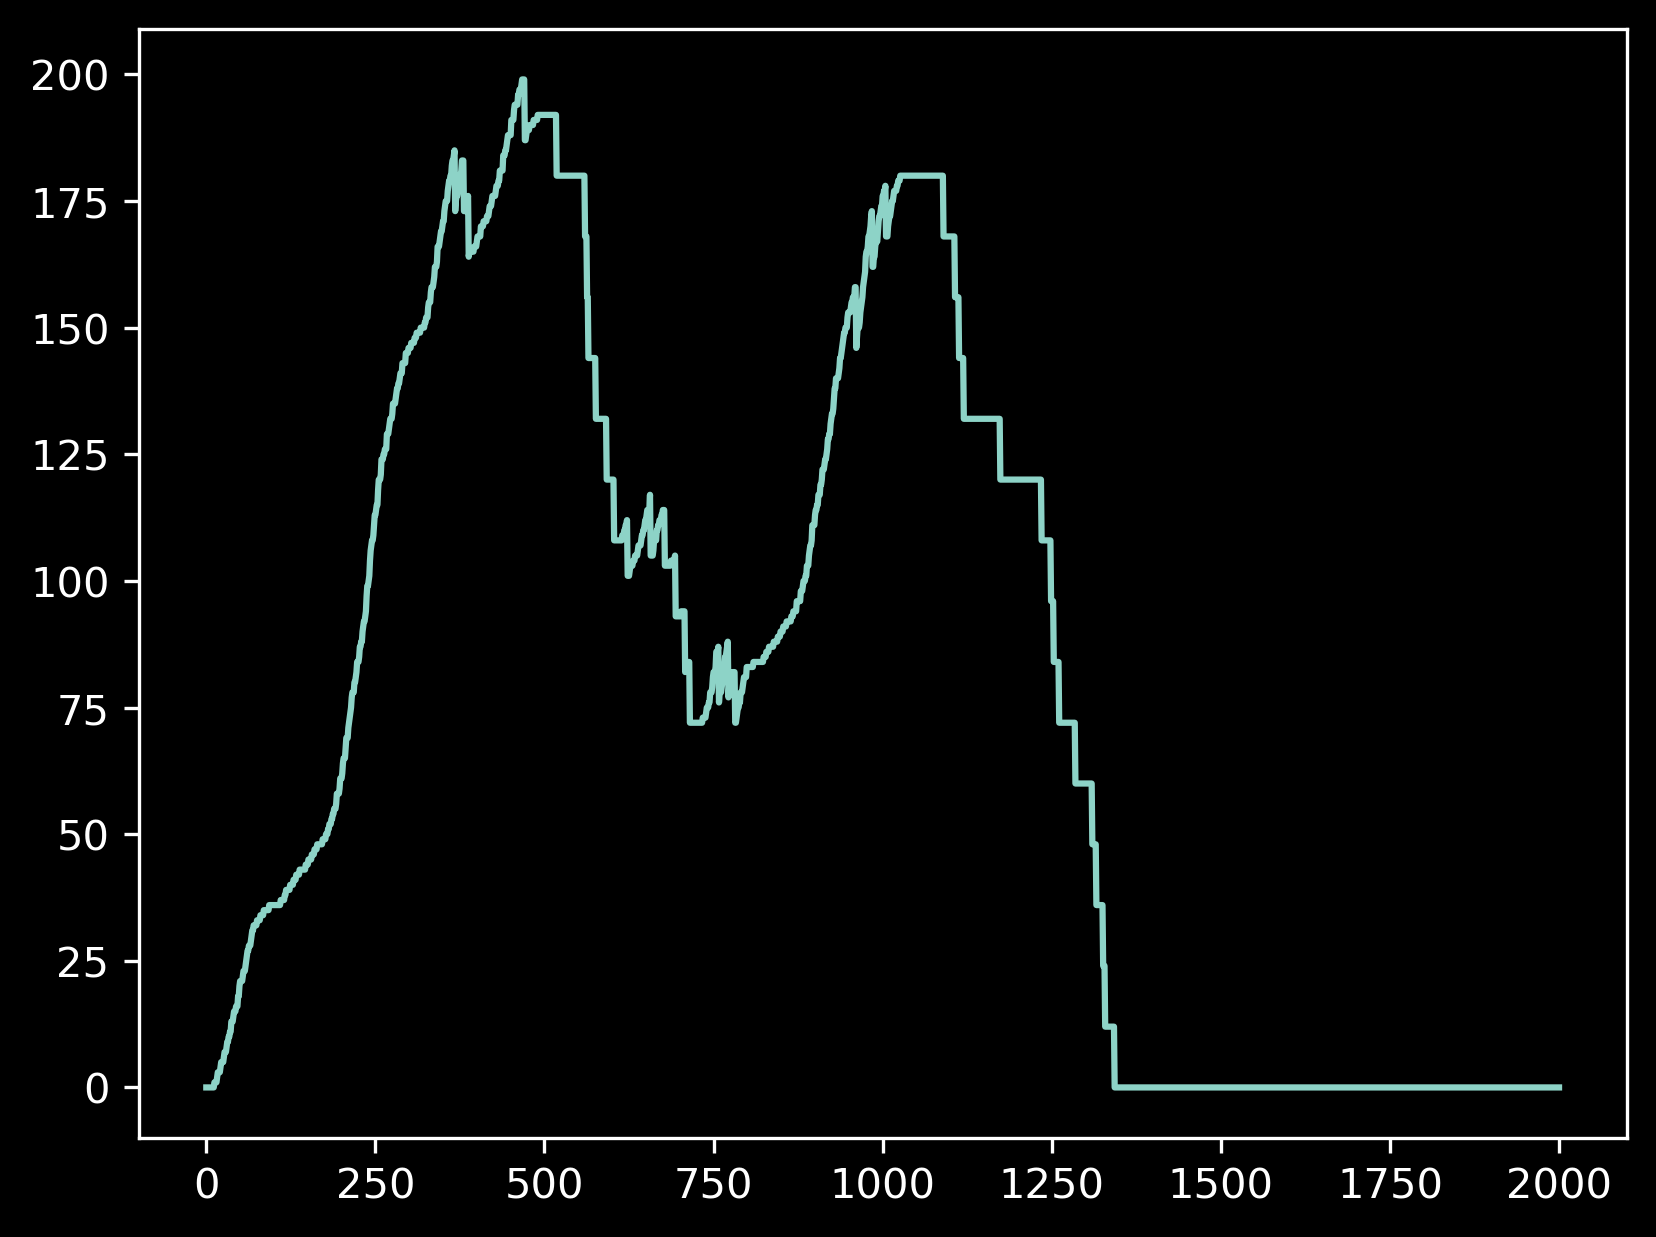

In [33]:
plt.plot(soln.I[0])

## rSNAPed


In [ ]:
#Quality of life functions

def show_vid(video_array):
    fig,ax = plt.subplots(1,1)
    maxes = np.array([max(video_array[:,:,:,i].flatten()) for i in [0,1,2]])
    maxes[2] = 14000
    im = plt.imshow(video_array[0]/maxes)
    frame_ids = np.arange(len(video_array))
    def animate(i):
        im.set_array(video_array[i]/maxes)

    ani = mpani.FuncAnimation(fig, animate, frames=len(video_array) + len(video_array))
    return HTML(ani.to_html5_video())

In [9]:
with open(r'C:\Users\willi\Documents\data_for_tim\kdm5b_12xSun.yaml', 'r') as f:
    config_dict = yaml.safe_load(f)

config_dict

{'name': 'Test Cell',
 'diffusion': {'initialization': {'start': 'uniform', 'parameters': []},
  'motion': {'diffusion_coefficient': 0.3, 'tstep': 1.0, 'elasticity': 1.0},
  'jitter': {'use': True,
   'n_channels': 3,
   'method': 'gaussian',
   'parameters': [0.2]},
  'simulate_z': {'use': False,
   'method': 'gaussian',
   'parmaeters': [0.3],
   'z_stack': 130,
   'min_dimming': 0.3}},
 'frame': {'quantile': 0.95,
  'spot_size': 15,
  'channel 0': {'background': {'source': 0,
    'method': 'gaussian',
    'parameters': [1]},
   'spots': {'sigma': 1,
    'intensity_scale': 10,
    'poisson_sample_spot': True,
    'photon_count': 600},
   'photobleaching': {'use': False,
    'method': 'normal_percent_loss',
    'parameters': [0.005, 0.001]}},
  'channel 1': {'background': {'source': 0,
    'method': 'gaussian',
    'parameters': [1]},
   'spots': {'sigma': 1,
    'intensity_scale': 250,
    'poisson_sample_spot': True,
    'photon_count': 600},
   'photobleaching': {'use': False,
    

In [ ]:
## Design Channel 0 (R)
'''

    channel 0:
        background:
            source: 0                   # which channel of the base video to use, 0 or 1 currently
            method: gaussian            # method for generating new frames, default gaussian fit of each pixel
            parameters: [1]             # parameters for generation: for gaussian this is the scale of the standard dev of the pixels
        
        spots:                          # spot options in this channel
            sigma: 1                    # sigma of the gaussian kernel of the spot
            intensity_scale: 10         # intensity scale to multiply the spot values by
            poisson_sample_spot: True   # sample from the kernel's poisson N photons
            photon_count: 600          # how many photons to sample, lower = more static and pixely spot]
            
        photobleaching:                 # photobleaching options for this channel
            use: False
            method: 'normal_percent_loss'   # photobleaching method for this channel
            parameters: [0.005, 0.001]     # photobleaching parameters for this channel


'''





In [34]:
cell_num = np.random.randint(0,7)
video = imread(video_dir.joinpath('cell_shape_'+str(cell_num)+'.tif'))
mask_image = imread(masks_dir.joinpath('mask_cell_shape_'+str(cell_num)+'.tif'))


rsnaped_settings_yaml = r'C:\Users\willi\Documents\data_for_tim\kdm5b_12xSun.yaml'
# Making the simulated cell class off of the kdm5b yaml
simulated_cell_KDM5B = rsed.SimCell2D(video, mask_image, rsnaped_settings_yaml)


In [37]:
n_spots = 20

t = np.linspace(0,1500,int(1500/10)) # 0 to 1500s with 10s framerate
video_array, simulated_intensity, spot_positions = simulated_cell_KDM5B.gen(n_spots, t, verbose=1, disk_buffer=False, buffer_size=25) #generate a video w/ our custom model


Generating spot motion.....
Generating/loading intensity for mRNAs 0.....
Using C++.....


Generating video frames: 100%|██████████| 150/150 [00:05<00:00, 26.06it/s]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


IndexError: index 150 is out of bounds for axis 0 with size 150

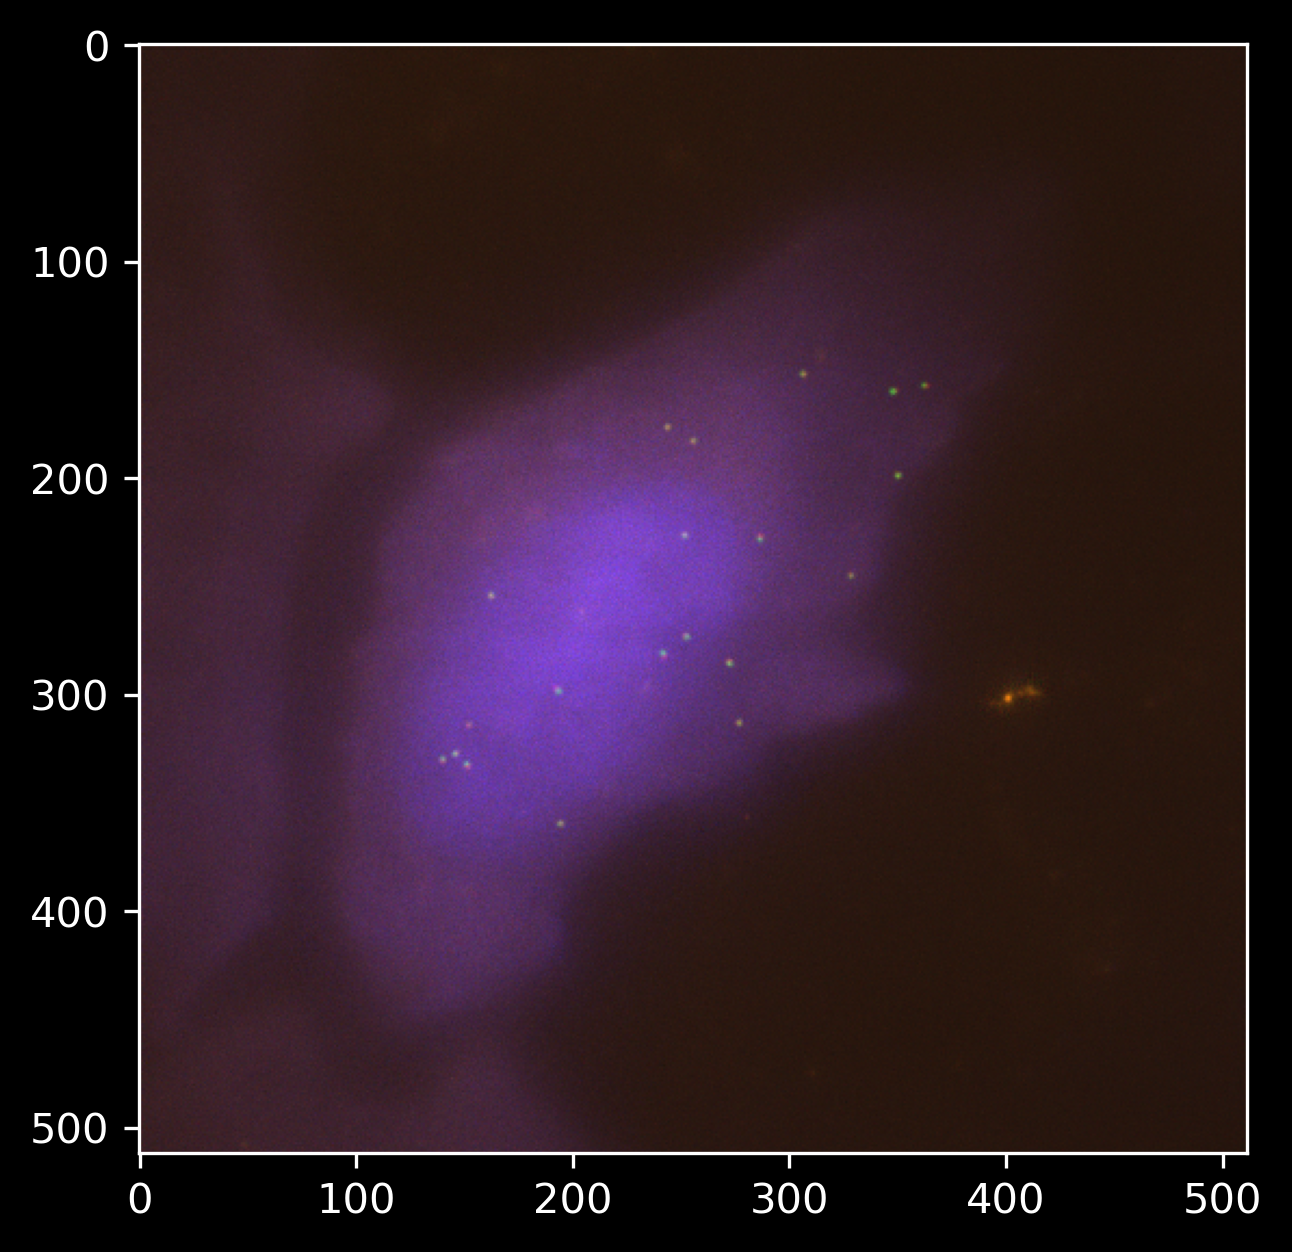

In [44]:
show_vid(video_array)